# English-to-Japanese Neural Machine Translation with Seq2Seq and Attention

## Project Overview

This project trains neural machine translation models that translate short English sentences into simplified Japanese. Three systems are compared on the same held-out test set:

1. **Retrieval baseline**: returns the Japanese translation of the most similar English sentence in the training data.
2. **Seq2Seq LSTM**: an encoder-decoder that compresses the whole source sentence into a single fixed-size vector.
3. **Seq2Seq LSTM with attention**: the same encoder-decoder, with Luong attention so that the decoder can look back at every source word while generating.

Translations are scored with character-level BLEU and chrF. The error analysis covers sentence length, translation length, attention alignments, and typical failure cases.

**Tools:** Python, PyTorch (CUDA), scikit-learn (retrieval baseline), NLTK (BLEU and chrF), pandas, matplotlib, seaborn.

## Objective

Build a working English→Japanese translator from scratch, and quantify how much attention improves a basic encoder-decoder, especially on longer sentences.

## Dataset

| Property | Value |
|---|---|
| Name | SNOW T15: Japanese Simplified Corpus with Core Vocabulary (Maruyama & Yamamoto, 2018) |
| Origin | English–Japanese sentence pairs from the Tanaka Corpus, with a simplified Japanese rewrite of each sentence |
| File | `data/english_japanese.csv` with columns `ID`, `japanese`, `#やさしい日本語` (simplified Japanese), `english` |
| Size | 50,000 sentence pairs; English sentences have 4–16 tokens |
| License | Creative Commons Attribution 4.0 (CC BY 4.0) |

The target is the **simplified Japanese** column, which uses a restricted core vocabulary. The English side is already lowercased and tokenized (for example, `i can 't tell who will arrive first .`).

## Setup and Imports

In [ ]:
import math
import random
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from matplotlib import font_manager
from nltk.translate.bleu_score import SmoothingFunction, corpus_bleu
from nltk.translate.chrf_score import corpus_chrf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neighbors import NearestNeighbors

RANDOM_SEED = 42
DATA_PATH = Path("data") / "english_japanese.csv"
HIDDEN_SIZE = 256
EMBED_SIZE = 256
BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 3
MAX_OUTPUT_CHARS = 40

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
# Use the first installed Japanese-capable font so the attention plots can show kana and kanji
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
japanese_font = next((f for f in ["Yu Gothic", "MS Gothic", "Noto Sans CJK JP", "Noto Sans JP",
                                  "IPAexGothic", "Hiragino Sans"] if f in installed_fonts), None)
if japanese_font:
    plt.rcParams["font.family"] = [japanese_font, "DejaVu Sans"]
else:
    print("No Japanese font found; install Noto Sans CJK JP to render the attention plot labels.")
warnings.filterwarnings("ignore", message="Glyph .* missing from font")
MODEL_COLORS = {"Retrieval baseline": "#8a8a8a", "Seq2Seq": "#eb6834", "Seq2Seq + attention": "#2a78d6"}
print(f"Device: {device}")

Device: cuda


## Data Preparation

- **Source (English)**: split on whitespace into word tokens. The vocabulary keeps words that appear at least twice in training. Rarer words map to `<unk>`.
- **Target (Japanese)**: modeled **character by character**. Japanese is written without spaces, so splitting it into words would require a separate morphological analyzer. Characters also keep the output vocabulary manageable (about 2,000 symbols) with no unknown words.
- **Split**: 90% / 5% / 5%, **grouped by English sentence**. The corpus contains repeated English sentences, and grouping ensures that a test sentence never appears in training with a different translation.

In [ ]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Expected the corpus at {DATA_PATH.resolve()}. See the Dataset section.")

corpus = pd.read_csv(DATA_PATH).rename(columns={"#やさしい日本語": "target"})[["english", "target"]].dropna()
corpus["english"] = corpus["english"].str.strip()
corpus["target"] = corpus["target"].str.strip()
print(f"Sentence pairs: {len(corpus):,} | unique English sentences: {corpus['english'].nunique():,}")

outer = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_SEED)
train_idx, holdout_idx = next(outer.split(corpus, groups=corpus["english"]))
holdout = corpus.iloc[holdout_idx]
inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
val_idx, test_idx = next(inner.split(holdout, groups=holdout["english"]))

splits = {
    "train": corpus.iloc[train_idx].reset_index(drop=True),
    "validation": holdout.iloc[val_idx].reset_index(drop=True),
    "test": holdout.iloc[test_idx].reset_index(drop=True),
}
assert not set(splits["train"]["english"]) & set(splits["test"]["english"])
pd.Series({name: len(df) for name, df in splits.items()}, name="pairs").to_frame().T

Sentence pairs: 50,000 | unique English sentences: 46,171


,train,validation,test
pairs,45040,2470,2490


In [ ]:
PAD, SOS, EOS, UNK = "<pad>", "<s>", "</s>", "<unk>"

source_counts = Counter(w for s in splits["train"]["english"] for w in s.split())
source_vocab = [PAD, UNK] + sorted(w for w, c in source_counts.items() if c >= 2)
target_vocab = [PAD, SOS, EOS, UNK] + sorted({ch for s in splits["train"]["target"] for ch in s})
source_to_id = {w: i for i, w in enumerate(source_vocab)}
target_to_id = {ch: i for i, ch in enumerate(target_vocab)}
PAD_ID, SOS_ID, EOS_ID = 0, target_to_id[SOS], target_to_id[EOS]


def encode_source(sentence):
    return [source_to_id.get(w, source_to_id[UNK]) for w in sentence.split()]


def encode_target(sentence):
    return [SOS_ID] + [target_to_id.get(ch, target_to_id[UNK]) for ch in sentence] + [EOS_ID]


def decode_target(ids):
    return "".join(target_vocab[i] for i in ids if i not in (PAD_ID, SOS_ID, EOS_ID))


test_unk_rate = np.mean([w not in source_to_id for s in splits["test"]["english"] for w in s.split()])
print(f"English vocabulary: {len(source_vocab):,} | Japanese characters: {len(target_vocab):,}")
print(f"Share of test English tokens unseen in the vocabulary: {test_unk_rate:.2%}")

English vocabulary: 3,916 | Japanese characters: 1,231
Share of test English tokens unseen in the vocabulary: 1.31%


## Exploratory Analysis

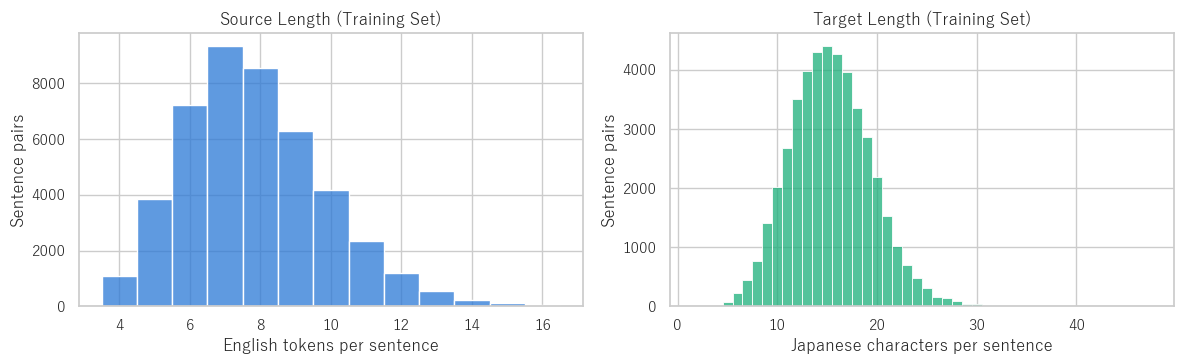

Correlation between source and target length: 0.49


,english,target
3789,not a word did she say to me .,彼女は私に少しの言葉もいわなかった。
12739,the door could not be opened .,ドアは開けられなかった。
18310,she is apt to keep a secret to herself .,彼女は秘密をよく守る。
24568,my mind is a blank .,私の心は寂しい。
34403,tom is the last person to break his promise .,トムは決して約束を破らない人である。


In [ ]:
lengths = pd.DataFrame({
    "English words": splits["train"]["english"].str.split().str.len(),
    "Japanese characters": splits["train"]["target"].str.len(),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.histplot(lengths["English words"], discrete=True, color="#2a78d6", ax=axes[0])
axes[0].set_title("Source Length (Training Set)")
axes[0].set_xlabel("English tokens per sentence")
axes[0].set_ylabel("Sentence pairs")
sns.histplot(lengths["Japanese characters"], discrete=True, color="#1baf7a", ax=axes[1])
axes[1].set_title("Target Length (Training Set)")
axes[1].set_xlabel("Japanese characters per sentence")
axes[1].set_ylabel("Sentence pairs")
plt.tight_layout()
plt.show()

print(f"Correlation between source and target length: {lengths.corr().iloc[0, 1]:.2f}")
splits["train"].sample(5, random_state=RANDOM_SEED)

## Model Development

### Baseline: nearest-neighbor retrieval

A simple but strong reference point: represent every English sentence as a TF-IDF vector over word unigrams and bigrams, find the most similar training sentence by cosine similarity, and return its Japanese translation unchanged. This baseline can only reuse existing translations and cannot compose new ones.

In [ ]:
retrieval_vectorizer = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 2), sublinear_tf=True)
train_vectors = retrieval_vectorizer.fit_transform(splits["train"]["english"])
neighbors = NearestNeighbors(n_neighbors=1, metric="cosine").fit(train_vectors)


def retrieval_translate(sentences):
    _, index = neighbors.kneighbors(retrieval_vectorizer.transform(sentences))
    return splits["train"]["target"].iloc[index[:, 0]].tolist()

### Encoder-decoder models

Both neural models share the same encoder and decoder sizes. The only difference is how the decoder reads the source:

- **Seq2Seq**: the encoder's final hidden and cell states initialize the decoder. The entire sentence must fit into that single vector, the same design as the original version of this project.
- **Seq2Seq + attention**: at each decoding step, the decoder scores every encoder output against its current state (Luong "general" attention), takes a weighted average as a context vector, and combines it with its own state before predicting the next character.

Training uses teacher forcing, meaning the decoder receives the correct previous character as input. The loss ignores padding. Each model stops early once validation loss has not improved for 3 epochs, and the best checkpoint is restored.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_SIZE, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(EMBED_SIZE, HIDDEN_SIZE, batch_first=True)

    def forward(self, source, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(self.embedding(source), lengths.cpu(),
                                                   batch_first=True, enforce_sorted=False)
        outputs, state = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True, total_length=source.shape[1])
        return outputs, state


class Decoder(nn.Module):
    def __init__(self, vocab_size, use_attention):
        super().__init__()
        self.use_attention = use_attention
        self.embedding = nn.Embedding(vocab_size, EMBED_SIZE, padding_idx=PAD_ID)
        self.lstm = nn.LSTM(EMBED_SIZE, HIDDEN_SIZE, batch_first=True)
        if use_attention:
            self.attention = nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE, bias=False)
            self.combine = nn.Linear(2 * HIDDEN_SIZE, HIDDEN_SIZE)
        self.output = nn.Linear(HIDDEN_SIZE, vocab_size)

    def forward(self, previous_tokens, state, encoder_outputs, source_mask):
        """Decode a whole target prefix at once (teacher forcing) or one step at a time."""
        decoded, state = self.lstm(self.embedding(previous_tokens), state)
        weights = None
        if self.use_attention:
            scores = torch.bmm(self.attention(decoded), encoder_outputs.transpose(1, 2))
            scores = scores.masked_fill(~source_mask[:, None, :], -1e9)
            weights = torch.softmax(scores, dim=-1)
            context = torch.bmm(weights, encoder_outputs)
            decoded = torch.tanh(self.combine(torch.cat([decoded, context], dim=-1)))
        return self.output(decoded), state, weights


class Seq2Seq(nn.Module):
    def __init__(self, use_attention):
        super().__init__()
        self.encoder = Encoder(len(source_vocab))
        self.decoder = Decoder(len(target_vocab), use_attention)

    def forward(self, source, source_lengths, target_input):
        encoder_outputs, state = self.encoder(source, source_lengths)
        logits, _, _ = self.decoder(target_input, state, encoder_outputs, source != PAD_ID)
        return logits

    @torch.no_grad()
    def translate(self, source, source_lengths, max_chars=MAX_OUTPUT_CHARS):
        """Greedy decoding for a batch. Returns token ids and attention weights."""
        self.eval()
        encoder_outputs, state = self.encoder(source, source_lengths)
        mask = source != PAD_ID
        token = torch.full((source.shape[0], 1), SOS_ID, device=source.device)
        outputs, attentions = [], []
        for _ in range(max_chars):
            logits, state, weights = self.decoder(token, state, encoder_outputs, mask)
            token = logits.argmax(dim=-1)
            outputs.append(token)
            if weights is not None:
                attentions.append(weights)
        outputs = torch.cat(outputs, dim=1).cpu().numpy()
        attentions = torch.cat(attentions, dim=1).cpu().numpy() if attentions else None
        return outputs, attentions

In [ ]:
def make_batches(df, shuffle):
    order = np.random.permutation(len(df)) if shuffle else np.arange(len(df))
    for start in range(0, len(df), BATCH_SIZE):
        rows = df.iloc[order[start:start + BATCH_SIZE]]
        sources = [torch.tensor(encode_source(s)) for s in rows["english"]]
        targets = [torch.tensor(encode_target(t)) for t in rows["target"]]
        source = nn.utils.rnn.pad_sequence(sources, batch_first=True, padding_value=PAD_ID).to(device)
        target = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_ID).to(device)
        lengths = torch.tensor([len(s) for s in sources])
        yield source, lengths, target


loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_ID)


def epoch_loss(model, df, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total, count = 0.0, 0
    with torch.set_grad_enabled(training):
        for source, lengths, target in make_batches(df, shuffle=training):
            logits = model(source, lengths, target[:, :-1])
            loss = loss_fn(logits.reshape(-1, logits.shape[-1]), target[:, 1:].reshape(-1))
            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            n_tokens = (target[:, 1:] != PAD_ID).sum().item()
            total += loss.item() * n_tokens
            count += n_tokens
    return total / count


def train(use_attention):
    torch.manual_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    model = Seq2Seq(use_attention).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    history, best_loss, best_state, stale = [], float("inf"), None, 0
    start = time.perf_counter()
    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = epoch_loss(model, splits["train"], optimizer)
        val_loss = epoch_loss(model, splits["validation"])
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        if val_loss < best_loss:
            best_loss, stale = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= PATIENCE:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), time.perf_counter() - start


neural_models, histories = {}, {}
for name, use_attention in [("Seq2Seq", False), ("Seq2Seq + attention", True)]:
    neural_models[name], histories[name], seconds = train(use_attention)
    best = histories[name]["val_loss"].min()
    print(f"{name}: {len(histories[name])} epochs in {seconds:.0f} s, best validation loss {best:.3f} "
          f"(perplexity {math.exp(best):.2f})")

Seq2Seq: 13 epochs in 65 s, best validation loss 1.398 (perplexity 4.05)


Seq2Seq + attention: 11 epochs in 61 s, best validation loss 1.280 (perplexity 3.60)


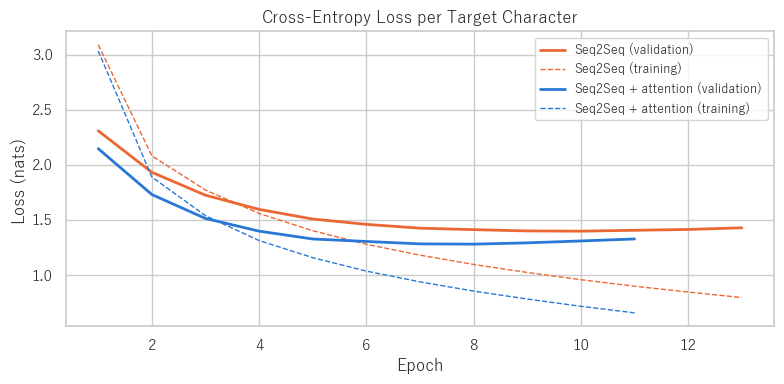

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, history in histories.items():
    ax.plot(history["epoch"], history["val_loss"], color=MODEL_COLORS[name], linewidth=2, label=f"{name} (validation)")
    ax.plot(history["epoch"], history["train_loss"], color=MODEL_COLORS[name], linewidth=1, linestyle="--",
            label=f"{name} (training)")
ax.set_title("Cross-Entropy Loss per Target Character")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (nats)")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## Model Evaluation

Each system translates the full test set with greedy decoding. Three metrics are reported:

- **Character-level BLEU-4**: n-gram precision over characters with a brevity penalty. Character-level scoring is common for Japanese because it avoids depending on a word segmenter.
- **chrF**: character n-gram F-score. It credits partially correct output and correlates well with human judgments for morphologically rich languages.
- **Exact match**: the share of translations identical to the reference.

In [ ]:
def neural_translate(model, df):
    hypotheses, attentions = [], []
    for source, lengths, _ in make_batches(df, shuffle=False):
        ids, weights = model.translate(source, lengths)
        for row, token_ids in enumerate(ids):
            end = list(token_ids).index(EOS_ID) if EOS_ID in token_ids else len(token_ids)
            hypotheses.append(decode_target(token_ids[:end]))
            attentions.append(weights[row, :end + 1] if weights is not None else None)
    return hypotheses, attentions


test_df = splits["test"]
references = test_df["target"].tolist()
translations = {"Retrieval baseline": retrieval_translate(test_df["english"].tolist())}
attention_maps = {}
for name, model in neural_models.items():
    translations[name], attention_maps[name] = neural_translate(model, test_df)

smoothing = SmoothingFunction().method1


def score(hypotheses, refs):
    return {
        "Char BLEU-4": corpus_bleu([[list(r)] for r in refs], [list(h) for h in hypotheses], smoothing_function=smoothing),
        "chrF": corpus_chrf(refs, hypotheses),
        "Exact match": np.mean([h == r for h, r in zip(hypotheses, refs)]),
    }


results = pd.DataFrame({name: score(hyps, references) for name, hyps in translations.items()}).T
results.round(3)

,Char BLEU-4,chrF,Exact match
Retrieval baseline,0.280,0.240,0.002
Seq2Seq,0.240,0.214,0.014
Seq2Seq + attention,0.298,0.261,0.023


In [ ]:
examples = test_df.sample(8, random_state=3).index
with pd.option_context("display.max_colwidth", 60):
    display(pd.DataFrame({
        "English": test_df.loc[examples, "english"],
        "Reference": test_df.loc[examples, "target"],
        **{name: [translations[name][i] for i in examples] for name in translations},
    }))

,English,Reference,Retrieval baseline,Seq2Seq,Seq2Seq + attention
2321,"arriving at the airport , i called her up .",空港に着いた時、私は彼女に電話をした。,私は彼女に電話をしました。,空港で彼女は電話をした。,空港に着いたら電話をした。
439,i regret that i told you .,あなたに話したことを後になって失敗だったと思っている。,助けられないのが残念に思います。,私はあなたがその事を言ったと言った。,私はあなたにそのことを言った。
1210,could you please turn your television down ?,テレビの音を小さくしてもらえませんか。,ラジオをの音を小さくしてくれませんか。,テレビを見てください。,あなたの声をかけてください。
2002,what 's the word for '' kaisha '' in english ?,「会社」を英語で何といいますか。,「会社」を表す英語は何ですか。,英語の言うことは何ですか。,「イギリスでは英語を英語に使えるのはどうですか。
2158,the students adore the new english teacher .,学生たちはその新しい英語の先生がいいなと思っている。,英語の先生になりたいのです。,学生たちは先生の新しい英語を学んだ。,学生たちは英語の先生が一番大きい。
1817,we all wish for happiness .,私たちはみんなの幸せを願う。,私たちは、世界平和を願っている。,私たちはみんな幸せを願っている。,私たちはみんなが幸せだった。
301,he didn 't have enough experience to cope with the probl...,彼にはその問題に対応する十分な経験がなかった。,日本政府は、その問題に対応することができない。,彼はその問題を答えるとは難しい。,彼はその問題について学ぶことができなかった。
565,dress yourself warmly before you go out .,あたたかくして行け。,出かける前に、ドアに鍵をかけてください。,外に出る前に出かけましょう。,出かけないで。


## Error Analysis

### 1. Quality by source sentence length

A fixed-size encoder vector has to hold more information as sentences get longer. Splitting the test set by English length shows whether attention mainly helps on long inputs.

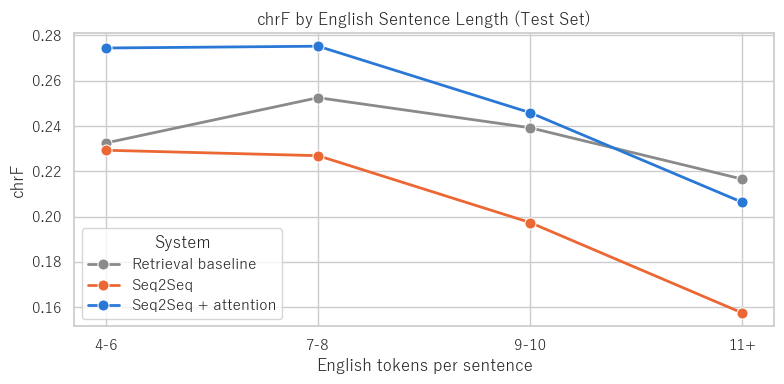

,Retrieval baseline,Seq2Seq,Seq2Seq + attention,Sentences
4-6,0.233,0.229,0.274,675
7-8,0.253,0.227,0.275,993
9-10,0.239,0.197,0.246,567
11+,0.217,0.157,0.206,255


In [ ]:
test_lengths = test_df["english"].str.split().str.len()
length_groups = pd.cut(test_lengths, bins=[0, 6, 8, 10, 20], labels=["4-6", "7-8", "9-10", "11+"])

length_rows = []
for group in length_groups.cat.categories:
    idx = np.where(length_groups == group)[0]
    for name, hyps in translations.items():
        length_rows.append({"Source tokens": group, "System": name, "Sentences": len(idx),
                            "chrF": corpus_chrf([references[i] for i in idx], [hyps[i] for i in idx])})
length_table = pd.DataFrame(length_rows)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=length_table, x="Source tokens", y="chrF", hue="System", palette=MODEL_COLORS,
             marker="o", linewidth=2, markersize=8, ax=ax)
ax.set_title("chrF by English Sentence Length (Test Set)")
ax.set_xlabel("English tokens per sentence")
ax.set_ylabel("chrF")
ax.legend(title="System", loc="lower left")
plt.tight_layout()
plt.show()

(length_table.pivot(index="Source tokens", columns="System", values="chrF")
 .reindex(length_groups.cat.categories).round(3)
 .join(length_table.groupby("Source tokens", observed=True)["Sentences"].first()))

### 2. Output length and repetition

Encoder-decoder models often stop too early or get stuck repeating characters. The ratio of output length to reference length, and the share of outputs that repeat the same character three or more times in a row, measure these two failure modes.

In [ ]:
def length_and_repetition(hypotheses):
    ratios = [len(h) / len(r) for h, r in zip(hypotheses, references)]
    repeated = [any(h[i] == h[i + 1] == h[i + 2] for i in range(len(h) - 2)) for h in hypotheses]
    reference_repeated = np.mean([any(r[i] == r[i + 1] == r[i + 2] for i in range(len(r) - 2)) for r in references])
    return {"Mean length ratio": np.mean(ratios), "Outputs with a 3x repeated character": np.mean(repeated),
            "References with a 3x repeated character": reference_repeated}


pd.DataFrame({name: length_and_repetition(h) for name, h in translations.items()}).T.round(3)

,Mean length ratio,Outputs with a 3x repeated character,References with a 3x repeated character
Retrieval baseline,0.973,0.001,0.0
Seq2Seq,0.984,0.002,0.0
Seq2Seq + attention,0.975,0.000,0.0


### 3. What the attention model looks at

Each row in these heatmaps is a generated Japanese character, and each column is an English source token. Bright cells show which source words the decoder attended to while producing that character. Japanese word order differs from English. For example, "much younger than Tom" becomes 「トムより…若い」 ("Tom-than… young"), so a good alignment has to jump back and forth across the source instead of moving left to right.

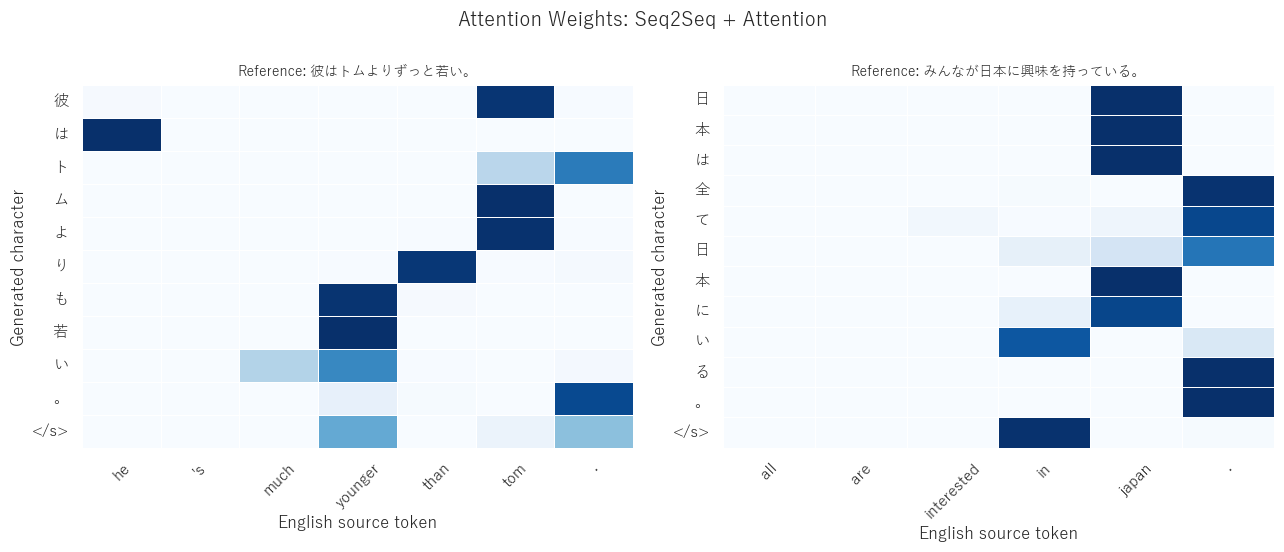

In [ ]:
attention_examples = [i for i in test_df.sample(200, random_state=7).index
                      if 6 <= len(test_df.loc[i, "english"].split()) <= 9][:2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, i in zip(axes, attention_examples):
    source_tokens = test_df.loc[i, "english"].split()
    output_chars = list(translations["Seq2Seq + attention"][i]) + ["</s>"]
    weights = attention_maps["Seq2Seq + attention"][i][:len(output_chars), :len(source_tokens)]
    sns.heatmap(weights, ax=ax, cmap="Blues", cbar=False, xticklabels=source_tokens, yticklabels=output_chars,
                vmin=0, vmax=1, linewidths=0.5, linecolor="white")
    ax.set_title(f"Reference: {test_df.loc[i, 'target']}", fontsize=10)
    ax.set_xlabel("English source token")
    ax.set_ylabel("Generated character")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
plt.suptitle("Attention Weights: Seq2Seq + Attention", y=1.0)
plt.tight_layout()
plt.show()

### 4. Lowest-scoring attention translations

Sentence-level chrF identifies the worst outputs of the best model.

In [ ]:
from nltk.translate.chrf_score import sentence_chrf

worst = pd.DataFrame({
    "English": test_df["english"],
    "Reference": references,
    "Attention output": translations["Seq2Seq + attention"],
    "chrF": [sentence_chrf(r, h) if h else 0.0 for r, h in zip(references, translations["Seq2Seq + attention"])],
    "Unknown source words": [sum(w not in source_to_id for w in s.split()) for s in test_df["english"]],
})
print(f"Mean unknown source words: worst 10% = {worst.nsmallest(len(worst) // 10, 'chrF')['Unknown source words'].mean():.2f}, "
      f"all = {worst['Unknown source words'].mean():.2f}")
worst.nsmallest(8, "chrF").round(3)

Mean unknown source words: worst 10% = 0.15, all = 0.10


,English,Reference,Attention output,chrF,Unknown source words
598,do you remember ?,覚えている？,あなたは運転が好きだったのか。,0.000,0
1008,watch your head !,頭の上に気をつけて！,お話しなさい。,0.000,0
1476,here comes a copper !,警察官がやってきたぞ。,「イギリスによろしく！,0.000,1
2489,"a little more to the right , so !",もう少し右の方へ—分かりました。,ほとんど、そう言う！,0.011,0
1841,come to me if you are in difficulties .,困ったら私のところへきたら。,いつも連絡を変えてください。,0.012,0
1562,every dog has his day .,誰にでもよい時代がある。,彼の犬は毎日死んだ。,0.014,0
827,get ready in advance .,前から準備しておけよ。,私には１０時になる。,0.015,0
2291,let your hair down a little .,気を楽に持とうよ。,あなたの髪は少しありません。,0.018,0


## Key Findings

| System (2,490 test pairs) | Char BLEU-4 | chrF | Exact match |
|---|---|---|---|
| Retrieval baseline (TF-IDF nearest neighbor) | 0.280 | 0.240 | 0.2% |
| Seq2Seq LSTM | 0.240 | 0.214 | 1.4% |
| **Seq2Seq LSTM + attention** | **0.298** | **0.261** | **2.3%** |

- **Attention is what makes the neural model competitive.** The basic encoder-decoder, the architecture of the original version of this project, scores *below* the simple retrieval baseline. Adding attention improves chrF by 22% (0.214 → 0.261) and makes it the best system on every metric, with slightly faster convergence (best validation loss 1.28 vs. 1.40).
- **The fixed-size bottleneck hurts on longer sentences.** Without attention, chrF falls from 0.229 on 4–6-token sentences to 0.157 on sentences with 11 or more tokens. With attention, quality holds up much better (0.274 → 0.206), although the retrieval baseline is still slightly ahead on the longest sentences.
- **The neural models compose new sentences; retrieval cannot.** The retrieval baseline almost never produces an exact match (0.2%), because a test sentence never appears verbatim in training. The attention model's exact-match rate is about ten times higher.
- **Attention learns Japanese word order.** In the attention plots, the decoder attends to *tom* before *younger* to produce 「トムより…若い」, reordering the source rather than reading it left to right.
- **Length and repetition are not the problem.** All systems produce outputs close to the reference length (ratio 0.97–0.98), and almost none get stuck repeating characters.
- **The remaining errors are mostly meaning errors on short, idiomatic sentences.** The lowest-scoring outputs include *every dog has his day* → 「彼の犬は毎日死んだ」 ("his dog died every day") and *let your hair down* → "your hair is a little missing". These idioms cannot be translated word by word. Unknown words play only a minor role: the worst 10% of outputs average 0.15 unknown source words, vs. 0.10 overall.

## Limitations

- The sentences are short (4–16 English tokens) and come from textbook-style examples. The models would not handle long, noisy, or domain-specific text.
- Each test sentence has one reference translation, while many valid translations exist. BLEU and chrF penalize correct paraphrases, so the scores understate translation quality.
- Greedy decoding picks the locally best character at each step. Beam search usually adds a few BLEU points.
- Both models are trained once with one seed. Small differences between runs are expected.

## Next Steps

- Add beam search and length normalization during decoding.
- Replace the LSTM with a small Transformer encoder-decoder and compare on the same split.
- Use subword tokenization (SentencePiece) on the Japanese side instead of characters

## Attribution

- Dataset: Maruyama, T., & Yamamoto, K. (2018). *Simplified Corpus with Core Vocabulary.* LREC. SNOW T15, released under CC BY 4.0. The English–Japanese pairs originate from the Tanaka Corpus